In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('Polynomail_regression-Prac.csv')
df.head()

Saving Polynomail_regression-Prac.csv to Polynomail_regression-Prac (1).csv


,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes
None
          Level          Salary
count  10.00000       10.000000
mean    5.50000   249500.000000
std     3.02765   299373.883668
min     1.00000    45000.000000
25%     3.25000    65000.000000
50%     5.50000   130000.000000
75%     7.75000   275000.000000
max    10.00000  1000000.000000


In [ ]:
df.isnull().any()

,0
Position,False
Level,False
Salary,False


In [ ]:
print(df.describe())

          Level          Salary
count  10.00000       10.000000
mean    5.50000   249500.000000
std     3.02765   299373.883668
min     1.00000    45000.000000
25%     3.25000    65000.000000
50%     5.50000   130000.000000
75%     7.75000   275000.000000
max    10.00000  1000000.000000


In [ ]:
df = df.rename(columns={'Position': 'Job Position', '	Level)': '	Level', 'Salary': 'Salary'})

In [ ]:
df.shape

(10, 3)

In [ ]:
df

,Job Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [ ]:
df['Level'] = pd.to_numeric(df['Level'], errors='coerce')
df['Salary'] = pd.to_numeric(df['Salary'], errors='coerce')

In [ ]:
df = df.dropna(subset=['Level', 'Salary'])

In [ ]:
df = df.reset_index(drop=True)

In [ ]:

#print("\n Cleaned Dataset:\n", df.head(5))
#print("\nDataset Info After Cleaning:")
#print(df.info())

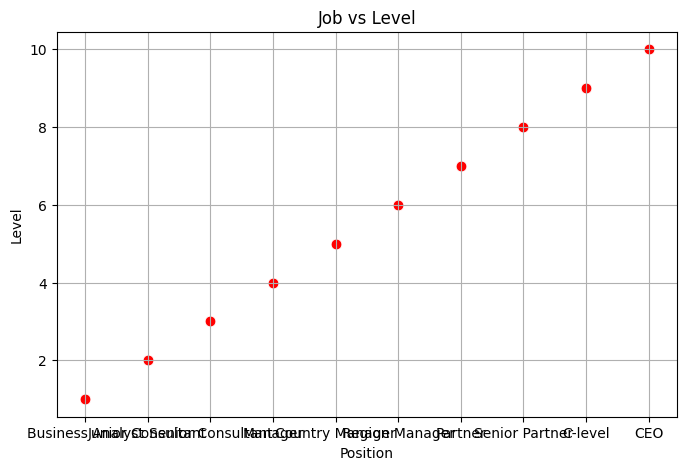

In [ ]:
# Visualization to verify
plt.figure(figsize=(8,5))
sns.scatterplot(x='Job Position', y='Level', data=df, color='red', s=60)
plt.title("Job vs Level")
plt.xlabel("Position")
plt.ylabel("Level")
plt.grid(True)
plt.show()

Objective:

The objective of this experiment is to implement
Classification Models namely Decision Tree,
Random Forest, and KNN on a practice dataset
to classify data into predefined categories.

These are supervised learning algorithms that
predict the class/category of the target variable
based on input features.

In [ ]:
X = df[['Salary']].values
y = df['Level'].values

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lin_reg = LinearRegression()
lin_reg.fit(X,y)
y_pred_linear = lin_reg.predict(X)
r2_linear = r2_score(y,y_pred_linear)

In [ ]:
poly2 = PolynomialFeatures(degree=2)
X_poly2 = poly2.fit_transform(X)

poly_reg2 = LinearRegression()
poly_reg2.fit(X_poly2, y)
y_pred_poly2 = poly_reg2.predict(X_poly2)
r2_poly2 = r2_score(y, y_pred_poly2)

In [ ]:
poly3 = PolynomialFeatures(degree=3)
X_poly3 = poly3.fit_transform(X)

poly_reg3 = LinearRegression()
poly_reg3.fit(X_poly3, y)
y_pred_poly3 = poly_reg3.predict(X_poly3)
r2_poly3 = r2_score(y, y_pred_poly3)

In [ ]:
# Step 5: Evaluate Models
print("\n Model Performance Comparison:")
print(f"Linear Regression R² Score: {r2_linear:.4f}")
print(f"Polynomial (Degree 2) R² Score: {r2_poly2:.4f}")
print(f"Polynomial (Degree 3) R² Score: {r2_poly3:.4f}")


 Model Performance Comparison:
Linear Regression R² Score: 0.6690
Polynomial (Degree 2) R² Score: 0.9093
Polynomial (Degree 3) R² Score: 0.9769


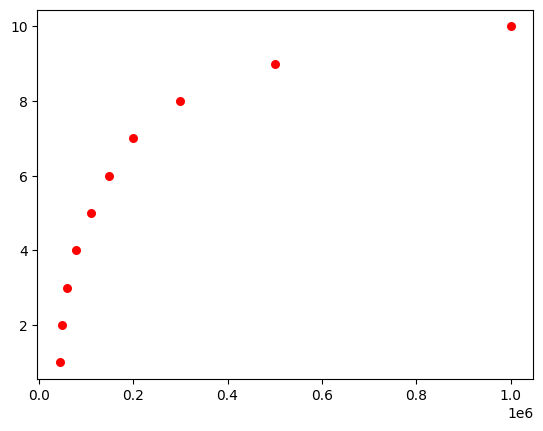

In [ ]:
# Sctter data
plt.scatter(X,y,color='red',label='Actual Data',s=30)

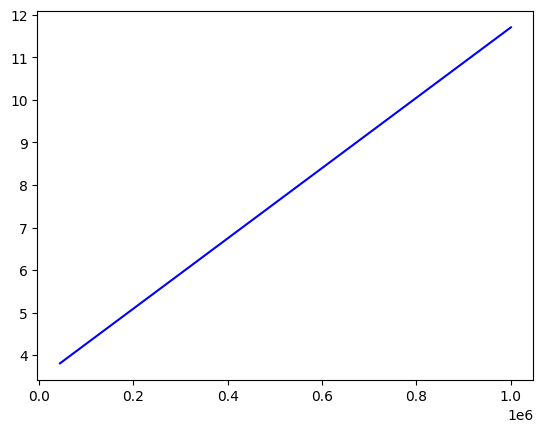

In [ ]:
# Linear Regression line
plt.plot(X,y_pred_linear, color='blue', label=f'Linear Fit (R={r2_linear:.3f}')

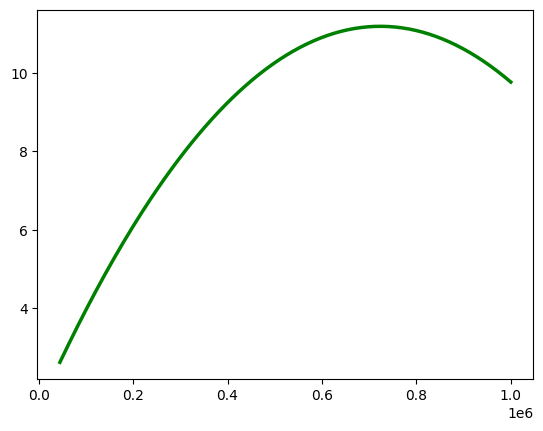

In [ ]:
# Polynomial (Degree 2) curve
X_grid = np.linspace(min(X), max(X), 200).reshape(-1,1)
plt.plot(X_grid, poly_reg2.predict(poly2.transform(X_grid)), color='green', linewidth=2.5,
         label=f'Polynomial (Degree 2) Fit (R²={r2_poly2:.3f})')

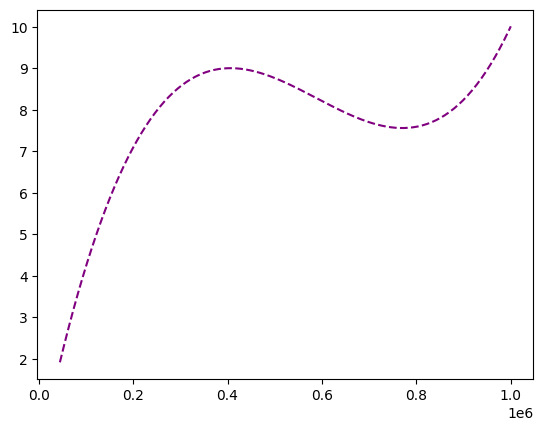

In [ ]:
# Polynomial Degree 3
plt.plot(X_grid, poly_reg3.predict(poly3.transform(X_grid)), color='purple',linestyle='--',
         label=f'Polynomial (Degree 3) Fit (R={r2_poly3:.3f})')

In [ ]:
# Model Evaluation Metrics
from sklearn.metrics import mean_squared_error

mse_poly2 = mean_squared_error(y, y_pred_poly2)
mse_poly3 = mean_squared_error(y, y_pred_poly3)

print("\nPolynomial Regression Model Details:")
print(f"Degree 2 Coefficients: {poly_reg2.coef_}")
print(f"Degree 2 Intercept: {poly_reg2.intercept_}")
print(f"Degree 2 MSE: {mse_poly2:.4f}")

print(f"\nDegree 3 Coefficients: {poly_reg3.coef_}")
print(f"Degree 3 Intercept: {poly_reg3.intercept_}")
print(f"Degree 3 MSE: {mse_poly3:.4f}")


Polynomial Regression Model Details:
Degree 2 Coefficients: [ 0.00000000e+00  2.69568237e-05 -1.86278446e-11]
Degree 2 Intercept: 1.436424325352199
Degree 2 MSE: 0.7482

Degree 3 Coefficients: [ 0.00000000e+00  5.61921043e-05 -1.05630388e-10  5.98547362e-17]
Degree 3 Intercept: -0.40099520657500864
Degree 3 MSE: 0.1908
